# DATA ENGINEERING

### Dataset: Cosmetics datasets


The dataset contains information about all beauty products from the Sephora online store, including product and brand names, prices, ingredients, ratings, and all features.

## Load dataset and libraries

In [1]:
import kagglehub

path = kagglehub.dataset_download("kingabzpro/cosmetics-datasets")

print("Path to dataset files:", path)

c:\Users\tanja\anaconda3\envs\sci-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 263k/263k [00:00<00:00, 571kB/s]

Extracting files...
Path to dataset files: C:\Users\tanja\.cache\kagglehub\datasets\kingabzpro\cosmetics-datasets\versions\1


In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os
import string
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import plotly.express as px





In [3]:
# List all files in the downloaded dataset directory
files = os.listdir(path)
print("Downloaded files:", files)

Downloaded files: ['cosmetics.csv']


## EDA

In [4]:
csv_file = os.path.join(path, "cosmetics.csv")
df = pd.read_csv(csv_file)

# Check the first few rows of the dataframe
print(df.head())

         Label           Brand                                           Name  \
0  Moisturizer          LA MER                                Crème de la Mer   
1  Moisturizer           SK-II                       Facial Treatment Essence   
2  Moisturizer  DRUNK ELEPHANT                     Protini™ Polypeptide Cream   
3  Moisturizer          LA MER                    The Moisturizing Soft Cream   
4  Moisturizer    IT COSMETICS  Your Skin But Better™ CC+™ Cream with SPF 50+   

   Price  Rank                                        Ingredients  \
0    175   4.1  Algae (Seaweed) Extract, Mineral Oil, Petrolat...   
1    179   4.1  Galactomyces Ferment Filtrate (Pitera), Butyle...   
2     68   4.4  Water, Dicaprylyl Carbonate, Glycerin, Ceteary...   
3    175   3.8  Algae (Seaweed) Extract, Cyclopentasiloxane, P...   
4     38   4.1  Water, Snail Secretion Filtrate, Phenyl Trimet...   

   Combination  Dry  Normal  Oily  Sensitive  
0            1    1       1     1          1  
1   

In [5]:
print("Shape of the DataFrame:", df.shape)
print(df.info())



Shape of the DataFrame: (1472, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1472 entries, 0 to 1471
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Label        1472 non-null   object 
 1   Brand        1472 non-null   object 
 2   Name         1472 non-null   object 
 3   Price        1472 non-null   int64  
 4   Rank         1472 non-null   float64
 5   Ingredients  1472 non-null   object 
 6   Combination  1472 non-null   int64  
 7   Dry          1472 non-null   int64  
 8   Normal       1472 non-null   int64  
 9   Oily         1472 non-null   int64  
 10  Sensitive    1472 non-null   int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 126.6+ KB
None


The data is clean (no missing values) and we have 1472 records and the following columns:

- Label: Category or product label.
- Brand: Brand name.
- Name: Product name.
- Price: Product price (integer).
- Rank: A rating or rank (float).
- Ingredients: A list or string of ingredients.
- Combination, Dry, Normal, Oily, Sensitive: indicate the suitability (as binary or count values) for different skin types.

In [6]:
# Summary statistics for numerical columns
print(df.describe())

# Summary for categorical columns
print(df[['Label', 'Brand', 'Name']].describe())

             Price         Rank  Combination          Dry       Normal  \
count  1472.000000  1472.000000   1472.00000  1472.000000  1472.000000   
mean     55.584239     4.153261      0.65625     0.614130     0.652174   
std      45.014429     0.633918      0.47512     0.486965     0.476442   
min       3.000000     0.000000      0.00000     0.000000     0.000000   
25%      30.000000     4.000000      0.00000     0.000000     0.000000   
50%      42.500000     4.300000      1.00000     1.000000     1.000000   
75%      68.000000     4.500000      1.00000     1.000000     1.000000   
max     370.000000     5.000000      1.00000     1.000000     1.000000   

              Oily    Sensitive  
count  1472.000000  1472.000000  
mean      0.607337     0.513587  
std       0.488509     0.499985  
min       0.000000     0.000000  
25%       0.000000     0.000000  
50%       1.000000     1.000000  
75%       1.000000     1.000000  
max       1.000000     1.000000  
              Label     Bra

### Price and Rank

In [35]:
print(df[['Price', 'Rank']].describe())

             Price         Rank
count  1472.000000  1472.000000
mean     55.584239     4.153261
std      45.014429     0.633918
min       3.000000     0.000000
25%      30.000000     4.000000
50%      42.500000     4.300000
75%      68.000000     4.500000
max     370.000000     5.000000


c:\Users\tanja\anaconda3\envs\sci-env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


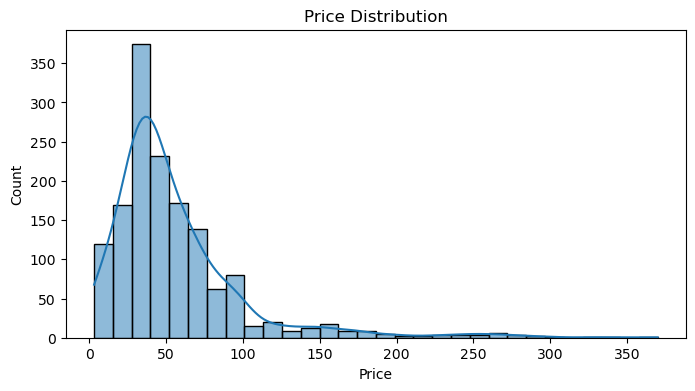

c:\Users\tanja\anaconda3\envs\sci-env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


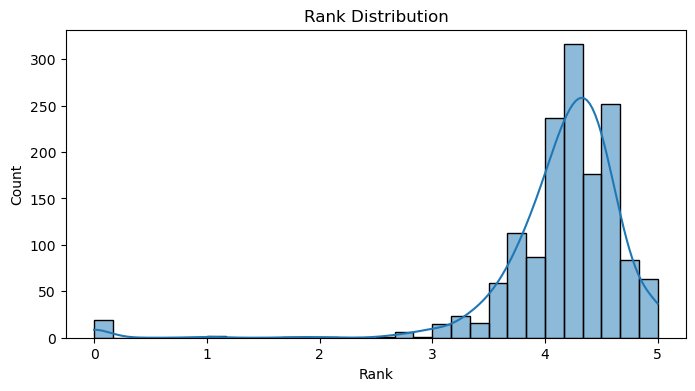

In [36]:
# Price distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['Price'], kde=True, bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

# Rank distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['Rank'], kde=True, bins=30)
plt.title("Rank Distribution")
plt.xlabel("Rank")
plt.show()


 The price distribution is right-skewed, indicating a few high-priced products. Most products are priced below 100. Most products are highly ranked (above 4), suggesting overall positive ratings.

### Categorical Variables

#### Labels and Brand

In [37]:
print("Unique Labels:", df['Label'].nunique())
print("Unique Brands:", df['Brand'].nunique())

Unique Labels: 6
Unique Brands: 116


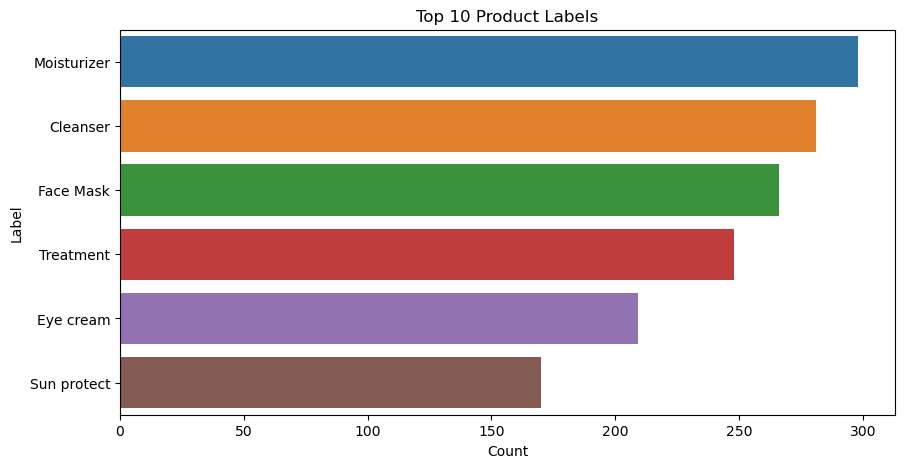

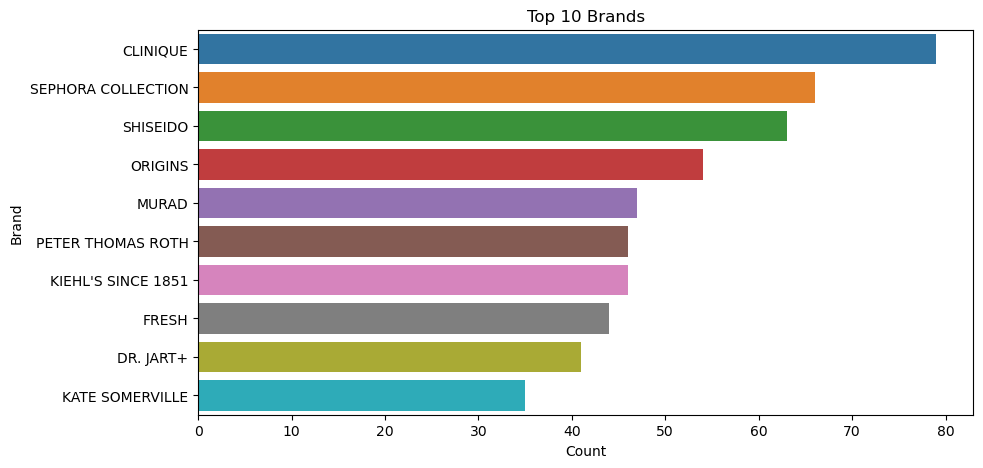

In [38]:
# Top 10 Labels
top_labels = df['Label'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_labels.values, y=top_labels.index)
plt.title("Top 10 Product Labels")
plt.xlabel("Count")
plt.ylabel("Label")
plt.show()

# Top 10 Brands
top_brands = df['Brand'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_brands.values, y=top_brands.index)
plt.title("Top 10 Brands")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.show()


Most common product types: Moisturizer, Cleanser, Face Mask, Treatment, Eye Cream, Sun Protect. Moisturizer is the most frequent label, appearing in over 300 products.

Leading brands include CLINIQUE, SEPHORA COLLECTION, SHISEIDO, ORIGINS, and others.
CLINIQUE leads with approximately 80 products, significantly ahead of others.

#### Skin Type

Unique skin types: Combination, Dry, Normal, Oily, Sensitive.

In [39]:
skin_types = ['Combination', 'Dry', 'Normal', 'Oily', 'Sensitive']
print(df[skin_types].sum())  # Shows total count for each skin type suitability flag


Combination    966
Dry            904
Normal         960
Oily           894
Sensitive      756
dtype: int64


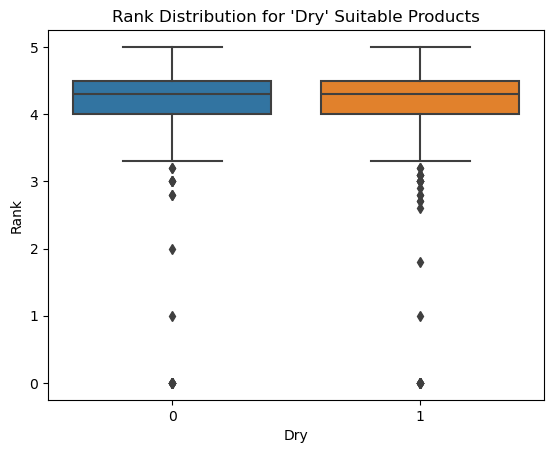

In [40]:
sns.boxplot(x='Dry', y='Rank', data=df)
plt.title("Rank Distribution for 'Dry' Suitable Products")
plt.show()


Average Suitability Scores:
Combination    0.656250
Dry            0.614130
Normal         0.652174
Oily           0.607337
Sensitive      0.513587
dtype: float64


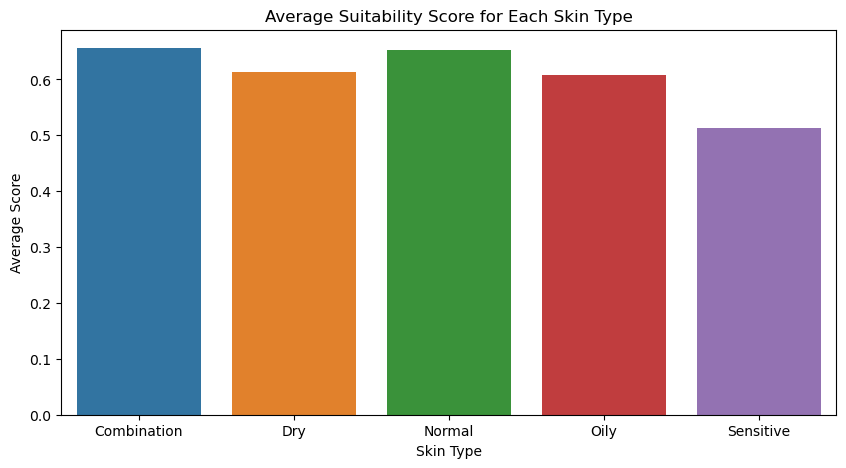

In [8]:
# Calculate the average suitability score for each skin type
avg_suitability = df[skin_types].mean()
print("Average Suitability Scores:")
print(avg_suitability)

# Plot the averages
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_suitability.index, y=avg_suitability.values)
plt.title("Average Suitability Score for Each Skin Type")
plt.xlabel("Skin Type")
plt.ylabel("Average Score")
plt.show()



Combination and Normal skin types have the highest scores.
Sensitive skin has the lowest average score, indicating fewer highly suitable products.

## Analyzing Ingredients

In [11]:
print(df['Ingredients'].head(10))


0    Algae (Seaweed) Extract, Mineral Oil, Petrolat...
1    Galactomyces Ferment Filtrate (Pitera), Butyle...
2    Water, Dicaprylyl Carbonate, Glycerin, Ceteary...
3    Algae (Seaweed) Extract, Cyclopentasiloxane, P...
4    Water, Snail Secretion Filtrate, Phenyl Trimet...
5    Water, Saccharomyces/Camellia Sinensis Leaf/Cl...
6    Water, Glycerin, Caprylic/ Capric Triglyceride...
7    100% Unrefined Sclerocraya Birrea (Marula) Ker...
8    Water, Glycerin, Cyclohexasiloxane, Squalane, ...
9    Algae (Seaweed) Extract, Mineral Oil, Petrolat...
Name: Ingredients, dtype: object


In [14]:
def process_ingredients(ingredient_str):
    # Convert to lower case
    ingredient_str = ingredient_str.lower()
    # Split by comma
    ingredients_list = ingredient_str.split(',')
    # Strip whitespace and remove punctuation for each ingredient
    ingredients_list = [
        ingredient.strip().translate(str.maketrans('', '', string.punctuation))
        for ingredient in ingredients_list
    ]
    return ingredients_list

# Apply the function to the Ingredients column and store the lists in a new column
df['Processed_Ingredients'] = df['Ingredients'].apply(process_ingredients)

# Display a few examples
print(df[['Ingredients', 'Processed_Ingredients']].head())

                                         Ingredients  \
0  Algae (Seaweed) Extract, Mineral Oil, Petrolat...   
1  Galactomyces Ferment Filtrate (Pitera), Butyle...   
2  Water, Dicaprylyl Carbonate, Glycerin, Ceteary...   
3  Algae (Seaweed) Extract, Cyclopentasiloxane, P...   
4  Water, Snail Secretion Filtrate, Phenyl Trimet...   

                               Processed_Ingredients  
0  [algae seaweed extract, mineral oil, petrolatu...  
1  [galactomyces ferment filtrate pitera, butylen...  
2  [water, dicaprylyl carbonate, glycerin, cetear...  
3  [algae seaweed extract, cyclopentasiloxane, pe...  
4  [water, snail secretion filtrate, phenyl trime...  


#### Frequency Count of Ingredients

Now that each product has a list of cleaned ingredients, we can count the frequency of each ingredient across the dataset. Visualize the top ingredients to gain insights into which ingredients are most prevalent.

             Ingredient  Count
3              glycerin   1014
23                water   1005
97       phenoxyethanol    884
43      butylene glycol    796
147       disodium edta    556
76   sodium hyaluronate    483
95      caprylyl glycol    473
109         dimethicone    443
91          xanthan gum    437
136  tocopheryl acetate    422


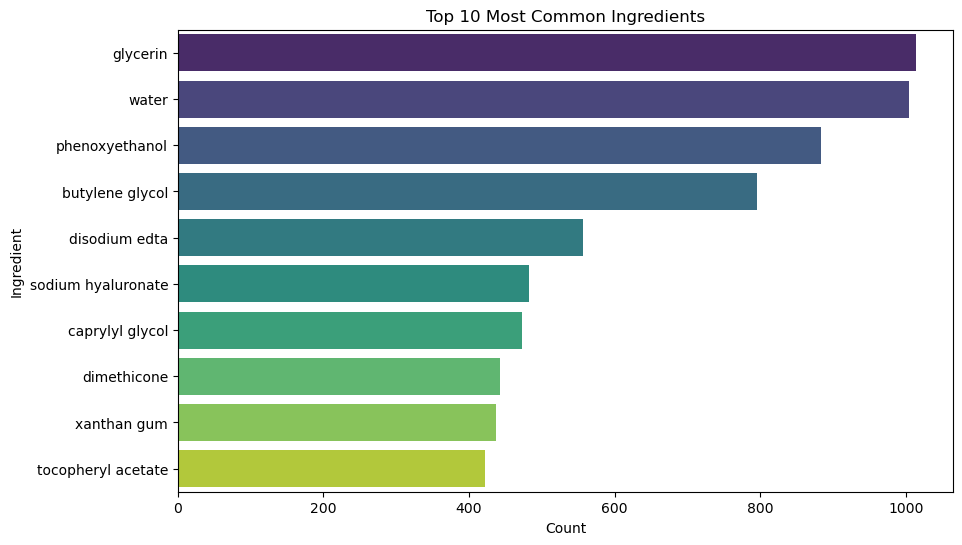

In [ ]:
# Create a counter for all ingredients
all_ingredients = [ingredient for ingredients in df['Processed_Ingredients'] for ingredient in ingredients]
ingredient_counts = Counter(all_ingredients)

# Convert to a DataFrame for better visualization
ingredient_counts_df = pd.DataFrame(ingredient_counts.items(), columns=['Ingredient', 'Count']).sort_values(by='Count', ascending=False)

print(ingredient_counts_df.head(10))
top_10 = ingredient_counts_df.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Ingredient', data=top_10, palette='viridis')
plt.title("Top 10 Most Common Ingredients")
plt.xlabel("Count")
plt.ylabel("Ingredient")
plt.show()

#### Ingredient Co-occurrence

In [18]:
unique_ingredients = list(ingredient_counts.keys())
ingredient_to_index = {ingredient: i for i, ingredient in enumerate(unique_ingredients)}

# Create a co-occurrence matrix
co_occurrence = np.zeros((len(unique_ingredients), len(unique_ingredients)), dtype=int)

# Populate the matrix by iterating through each product's ingredient list
for ingredients in df['Processed_Ingredients']:
    for i in range(len(ingredients)):
        for j in range(i + 1, len(ingredients)):
            idx1 = ingredient_to_index[ingredients[i]]
            idx2 = ingredient_to_index[ingredients[j]]
            co_occurrence[idx1, idx2] += 1
            co_occurrence[idx2, idx1] += 1

# For demonstration, print the co-occurrence counts for the top 5 ingredients
top_ingredients = top_10['Ingredient'].tolist()
for ingredient in top_ingredients:
    idx = ingredient_to_index[ingredient]
    print(f"Co-occurrences for {ingredient}:")
    for other in top_ingredients:
        if other != ingredient:
            other_idx = ingredient_to_index[other]
            print(f"  with {other}: {co_occurrence[idx, other_idx]}")

Co-occurrences for glycerin:
  with water: 867
  with phenoxyethanol: 896
  with butylene glycol: 799
  with disodium edta: 525
  with sodium hyaluronate: 474
  with caprylyl glycol: 492
  with dimethicone: 405
  with xanthan gum: 521
  with tocopheryl acetate: 393
Co-occurrences for water:
  with glycerin: 867
  with phenoxyethanol: 737
  with butylene glycol: 665
  with disodium edta: 470
  with sodium hyaluronate: 399
  with caprylyl glycol: 391
  with dimethicone: 363
  with xanthan gum: 361
  with tocopheryl acetate: 327
Co-occurrences for phenoxyethanol:
  with glycerin: 896
  with water: 737
  with butylene glycol: 713
  with disodium edta: 496
  with sodium hyaluronate: 405
  with caprylyl glycol: 454
  with dimethicone: 385
  with xanthan gum: 465
  with tocopheryl acetate: 381
Co-occurrences for butylene glycol:
  with glycerin: 799
  with water: 665
  with phenoxyethanol: 713
  with disodium edta: 469
  with sodium hyaluronate: 395
  with caprylyl glycol: 389
  with dimethic

####  Flagging Water-Based and Silicone-Based Products

Determine if certain ingredients are associated with higher product ratings or better suitability for specific skin types. Group products by the presence of a specific ingredient and compare the average rating or skin type suitability.

In [19]:
# Create a boolean flag for the presence of "water" in the processed ingredients list
df['contains_water'] = df['Processed_Ingredients'].apply(lambda x: 'water' in x)

# Compare average Rank for products containing water vs. those that don't
avg_rank_with_water = df[df['contains_water']]['Rank'].mean()
avg_rank_without_water = df[~df['contains_water']]['Rank'].mean()

print("Average Rank for products containing water:", avg_rank_with_water)
print("Average Rank for products not containing water:", avg_rank_without_water)


Average Rank for products containing water: 4.1424
Average Rank for products not containing water: 4.176271186440678


... not so useful

Add features (binary columns) indicating whether a product is water-based, silicone-based,

In [41]:
# Define key identifiers for water and silicone
water_keywords = ['water']
silicone_keywords = ['cyclopentasiloxane', 'cyclohexasiloxane', 'dimethicone', 'silicone']

# Create flags indicating the presence of water-based or silicone-based ingredients
df['water_based'] = df['Processed_Ingredients'].apply(lambda ingredients: any(keyword in ingredients for keyword in water_keywords))
df['silicone_based'] = df['Processed_Ingredients'].apply(lambda ingredients: any(keyword in ingredients for keyword in silicone_keywords))

# Check the result
print(df[['Name', 'water_based', 'silicone_based']].head(5))


                                            Name  water_based  silicone_based
0                                Crème de la Mer         True           False
1                       Facial Treatment Essence         True           False
2                     Protini™ Polypeptide Cream         True           False
3                    The Moisturizing Soft Cream         True            True
4  Your Skin But Better™ CC+™ Cream with SPF 50+         True            True


#### Vectorize

Vectorize the processed ingredients for each product (using methods such as TF-IDF or a simple bag-of-words model).  This converts each product's ingredients into a numerical representation, capturing the importance of each ingredient relative to the entire dataset.Compute similarity scores between products based on their TF-IDF vectors. This matrix indicates how similar products are to one another in terms of their ingredients.

In [23]:
# Join the processed ingredients into a single string for each product
df['ingredients_text'] = df['Processed_Ingredients'].apply(lambda x: ' '.join(x))

# Create a TF-IDF vectorizer and transform the text data
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['ingredients_text'])

# Compute the cosine similarity matrix between products
ingredient_similarity = cosine_similarity(tfidf_matrix)

Similarity-Based Recommendations,  when a user likes a particular product, we can recommend other products with high cosine similarity scores based on ingredients. We select a subset (first 50 products) of the similarity matrix and plot a heatmap. This helps visualize the similarity patterns between products.

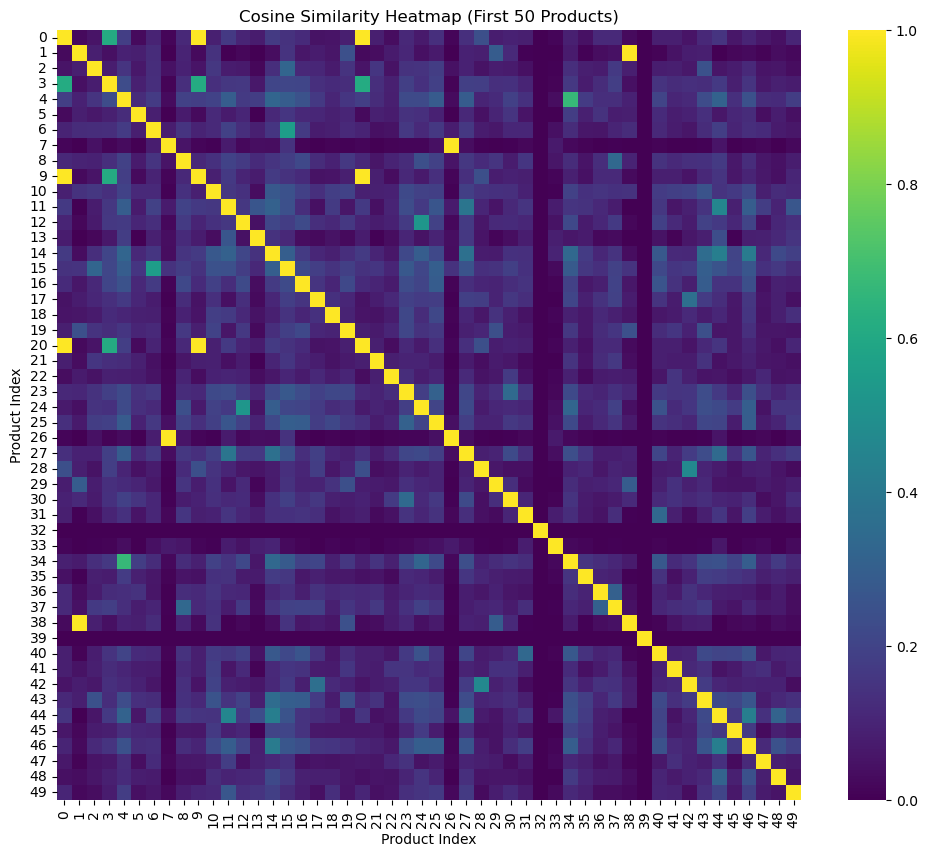

In [28]:
# Select a subset (for example, the first 50 products)
subset_size = 50
subset_similarity = ingredient_similarity[:subset_size, :subset_size]

plt.figure(figsize=(12, 10))
sns.heatmap(subset_similarity, cmap='viridis', annot=False)
plt.title("Cosine Similarity Heatmap (First 50 Products)")
plt.xlabel("Product Index")
plt.ylabel("Product Index")
plt.show()

A heatmap is plotted using Seaborn, which shows pairwise cosine similarity values for this subset. Areas with higher similarity appear yellow, making it easier to see clusters of similar products.

Another visualization reduces the TF-IDF vectors (which are high-dimensional) down to 2 dimensions using PCA, and then creates a scatter plot of the products. This 2D projection helps visually inspect how products cluster based on their ingredients.

C:\Users\tanja\AppData\Local\Temp\ipykernel_6328\2003496346.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1], s=50, palette='viridis')


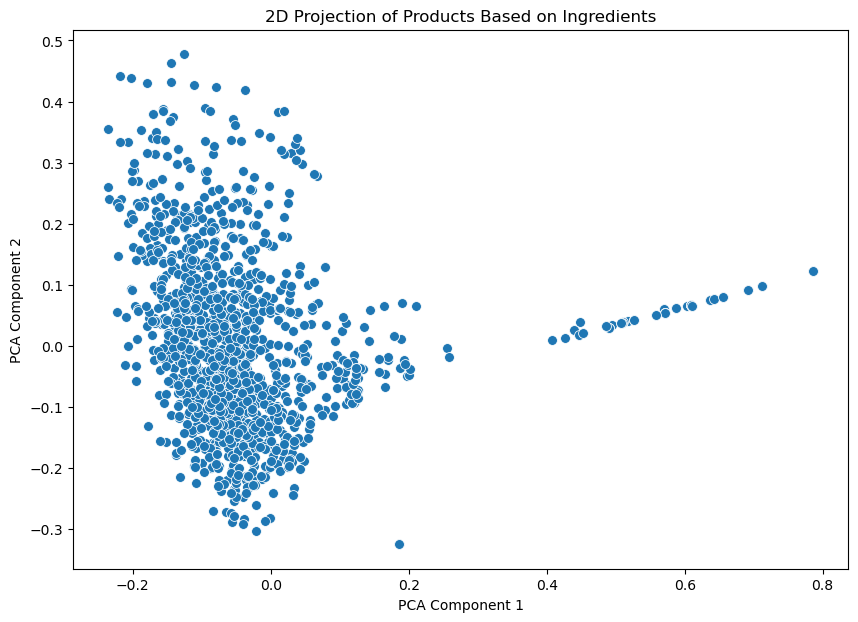

In [29]:
# Reduce dimensions to 2 for visualization
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(10, 7))
sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1], s=50, palette='viridis')
plt.title("2D Projection of Products Based on Ingredients")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


In [45]:
# Calculate Euclidean distances from the origin for each point
distances = np.linalg.norm(reduced_data, axis=1)

# Choose a threshold to define an "outlier" (this is heuristic; adjust based on your visualization)
threshold = np.percentile(distances, 90)  # for example, points in the top 10% distance

# Get indices of potential outliers
outlier_indices = np.where(distances > threshold)[0]
print("Outlier indices:", outlier_indices)

# Inspect the product details for these outliers
print(df.iloc[outlier_indices][['Name', 'Label', 'Brand', 'Ingredients']])

Outlier indices: [  11   14   27   32   44   55   58   95   98  108  109  113  123  138
  140  152  160  161  169  191  202  204  206  210  228  239  240  250
  251  252  257  258  271  277  280  283  301  316  330  347  353  358
  382  403  408  421  427  438  445  450  455  466  478  487  498  500
  512  517  518  521  523  528  574  585  617  622  632  663  667  671
  698  701  706  707  718  722  724  726  745  755  766  775  776  796
  813  820  821  825  829  854  859  860  891  905  912  924  930  951
  972 1008 1010 1014 1019 1035 1065 1074 1115 1155 1159 1160 1162 1173
 1180 1182 1186 1189 1191 1194 1200 1204 1210 1227 1228 1229 1248 1253
 1257 1270 1271 1277 1287 1302 1303 1305 1317 1318 1321 1341 1347 1349
 1351 1362 1369 1373 1396 1436 1462 1471]
                                                   Name        Label  \
11                        Midnight Recovery Concentrate  Moisturizer   
14    Honeymoon Glow AHA Resurfacing Night Serum wit...  Moisturizer   
27    Dr. Andre

PROBLEM:  some prosucts do not have actual ingridients listed

In [69]:
# Create a mask for rows where 'Ingredients' contains 'Visit the' (placeholder text)
placeholder_mask = df['Ingredients'].str.contains('Visit the', case=False, na=False)
num_placeholder = placeholder_mask.sum()
print("Number of products with placeholder ingredient text:", num_placeholder)

# Create a mask for rows where 'Ingredients' contains 'no info'
no_info_mask = df['Ingredients'].str.contains('no info', case=False, na=False)
num_no_info = no_info_mask.sum()
print("Number of products with 'no info' in ingredients:", num_no_info)



Number of products with placeholder ingredient text: 120
Number of products with 'no info' in ingredients: 23


Dropping 146 products reduces your dataset size. However, if the remaining products (about 1352) still represent a diverse and sufficient sample of the market, this impact is minimal.

In [70]:
# Create a mask for rows where 'Ingredients' contains 'visit the'
placeholder_mask = df['Ingredients'].str.contains('visit the', case=False, na=False)

# Create a mask for rows where 'Ingredients' contains 'no info'
no_info_mask = df['Ingredients'].str.contains('no info', case=False, na=False)

# Combine both masks using the OR operator
combined_mask = placeholder_mask | no_info_mask

# Count how many rows match either condition
num_removals = combined_mask.sum()
print("Number of products with placeholder ingredient text or 'no info':", num_removals)

# Filter out these rows and reset the index
df_clean = df[~combined_mask].reset_index(drop=True)

# Verify the new shape of your DataFrame
print("New shape of DataFrame after dropping placeholder and 'no info' entries:", df_clean.shape)


Number of products with placeholder ingredient text or 'no info': 143
New shape of DataFrame after dropping placeholder and 'no info' entries: (1329, 19)


Re-run the vectorization on your cleaned DataFrame (i.e., after removing the 146 products with placeholder ingredient data). This ensures that your TF-IDF matrix and any subsequent similarity or clustering analyses are based solely on the valid ingredient information.

In [94]:

# Recreate the ingredients_text column for the cleaned DataFrame
df_clean['ingredients_text'] = df_clean['Processed_Ingredients'].apply(lambda x: ' '.join(x))

# Recompute the TF-IDF matrix on the cleaned data
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix_clean = vectorizer.fit_transform(df_clean['ingredients_text'])

ingredient_similarity_clean = cosine_similarity(tfidf_matrix_clean)


#### Clustering

Cluster products based on their ingredients. This way, each product gets assigned to a cluster (e.g., predominantly water-based, predominantly silicone-based, or mixed). Then, when recommending products, you can suggest items from the same cluster.

In [83]:
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(tfidf_matrix_clean)
df_clean['ingredient_cluster'] = cluster_labels

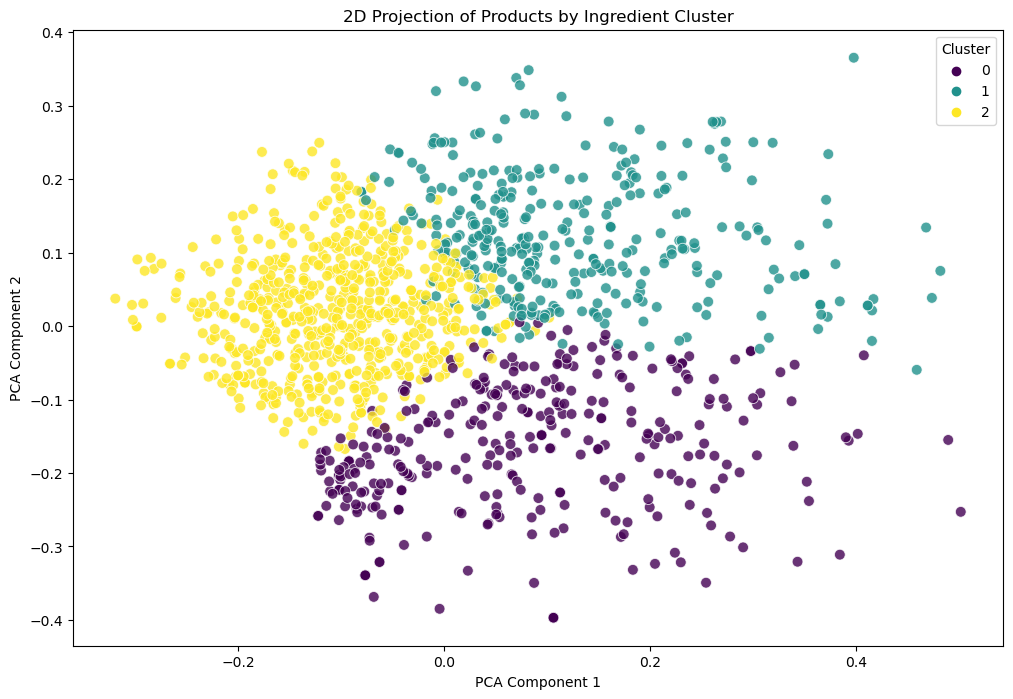

In [84]:
pca = PCA(n_components=2, random_state=42)
reduced_data = pca.fit_transform(tfidf_matrix_clean.toarray())
df_clean['pca1'] = reduced_data[:, 0]
df_clean['pca2'] = reduced_data[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_clean, x='pca1', y='pca2', hue='ingredient_cluster', 
                palette='viridis', s=60, alpha=0.8)
plt.title("2D Projection of Products by Ingredient Cluster")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

## Export the cleaned dataset

In [88]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1329 entries, 0 to 1328
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Label                  1329 non-null   object 
 1   Brand                  1329 non-null   object 
 2   Name                   1329 non-null   object 
 3   Price                  1329 non-null   int64  
 4   Rank                   1329 non-null   float64
 5   Ingredients            1329 non-null   object 
 6   Combination            1329 non-null   int64  
 7   Dry                    1329 non-null   int64  
 8   Normal                 1329 non-null   int64  
 9   Oily                   1329 non-null   int64  
 10  Sensitive              1329 non-null   int64  
 11  Processed_Ingredients  1329 non-null   object 
 12  contains_water         1329 non-null   bool   
 13  water_based            1329 non-null   bool   
 14  silicone_based         1329 non-null   bool   
 15  ingr


- **Initial Dataset:**  
  - Originally contained 1472 entries.
  
- **Data Cleaning:**  
  - **Removal of Placeholder Entries:**  
    - Dropped rows where the `Ingredients` column contained placeholder text such as "Visit the ..." or "no info".  
    - Final dataset now contains **1329 entries**.

- **Feature Engineering:**  
  - **Processed Ingredients:**  
    - Created a new column `Processed_Ingredients` that contains a list of cleaned ingredients (converted to lowercase, punctuation removed, whitespace stripped).
  - **Ingredients Text:**  
    - Joined the processed ingredients into a single string for each product and stored in the column `ingredients_text` (used for TF-IDF vectorization).
  - **Flag Columns:**  
    - `contains_water`: Indicates if the ingredient list contains the term "water".  
    - `water_based`: Boolean flag for water-based formulations.  
    - `silicone_based`: Boolean flag for silicone-based formulations.
  
- **Machine Learning & Clustering:**  
  - **TF-IDF Vectorization:**  
    - Applied TF-IDF vectorization on the `ingredients_text` column to generate a numerical representation of ingredient profiles.
  - **Clustering:**  
    - Applied KMeans clustering (with 3 clusters) on the TF-IDF vectors to create the `ingredient_cluster` column.
  - **Dimensionality Reduction:**  
    - Performed PCA on the TF-IDF matrix to reduce the data to 2 dimensions, with results stored in `pca1` and `pca2` columns for visualization purposes.


In [87]:
# Export the cleaned DataFrame to CSV
df_clean.to_csv("clean_cosmetics_data.csv", index=False)


## Test functions

----export later in another file

It prints out the product indices, similarity scores, and names of the recommended products.

In [89]:
def get_similar_products_by_cluster(product_index, similarity_matrix, df, top_n=5):
    """
    Return top_n similar products within the same ingredient cluster as the given product.
    """
    # Get the cluster of the selected product
    selected_cluster = df.loc[product_index, 'ingredient_cluster']
    
    # Get indices of products in the same cluster
    cluster_indices = df[df['ingredient_cluster'] == selected_cluster].index.tolist()
    
    # Compute similarity scores only within the cluster
    cluster_similarities = [(i, similarity_matrix[product_index][i]) for i in cluster_indices if i != product_index]
    cluster_similarities = sorted(cluster_similarities, key=lambda x: x[1], reverse=True)
    
    # Return the top_n similar products
    return cluster_similarities[:top_n]

The function get_similar_products_by_cluster first finds which cluster the selected product belongs to. Example

In [90]:
similar_products_cluster = get_similar_products_by_cluster(0, ingredient_similarity, df_clean, top_n=5)
print("Top similar products (within the same cluster) for product 0:")
for idx, score in similar_products_cluster:
    print(f"Product index: {idx}, Similarity: {score:.2f}, Name: {df.loc[idx, 'Name']}")

Top similar products (within the same cluster) for product 0:
Product index: 9, Similarity: 1.00, Name: Little Miss Miracle Limited-Edition Crème de la Mer
Product index: 20, Similarity: 1.00, Name: Crème de la Mer Mini
Product index: 413, Similarity: 0.65, Name: The Cleansing Gel
Product index: 587, Similarity: 0.62, Name: The Concentrate
Product index: 293, Similarity: 0.60, Name: The Moisturizing Matte Lotion


###  Recommendation function

In [92]:
def recommend_cosmetics(
    skin_type, 
    label_filter, 
    rank_filter, 
    brand_filter, 
    price_range, 
    ingredient_input=None, 
    num_recommendations=10,
    vectorizer=vectorizer,   # Precomputed vectorizer
    tfidf_matrix=tfidf_matrix  # Precomputed TF-IDF matrix
):
    # Start filtering based on skin type
    recommended_products = df[df[skin_type] == 1]
    
    # Apply label filter if provided
    if label_filter != 'All':
        recommended_products = recommended_products[recommended_products['Label'] == label_filter]
    
    # Filter based on Rank
    recommended_products = recommended_products[
        (recommended_products['Rank'] >= rank_filter[0]) & 
        (recommended_products['Rank'] <= rank_filter[1])
    ]
    
    # Filter based on brand if provided
    if brand_filter != 'All':
        recommended_products = recommended_products[recommended_products['Brand'] == brand_filter]
    
    # Filter based on Price
    recommended_products = recommended_products[
        (recommended_products['Price'] >= price_range[0]) & 
        (recommended_products['Price'] <= price_range[1])
    ]
    
    # If an ingredient input is provided, filter based on ingredient similarity
    if ingredient_input:
        # Transform the ingredient input using the precomputed vectorizer
        input_vec = vectorizer.transform([ingredient_input])
        from sklearn.metrics.pairwise import cosine_similarity
        cosine_similarities = cosine_similarity(input_vec, tfidf_matrix).flatten()
        
        # Get indices of the top recommendations based on ingredient similarity
        recommended_indices = cosine_similarities.argsort()[-num_recommendations:][::-1]
        ingredient_recommendations = df.iloc[recommended_indices]
        
        # Intersect with the filtered products
        recommended_products = recommended_products[recommended_products.index.isin(ingredient_recommendations.index)]
    
    # Return the top recommendations sorted by Rank (or any other metric)
    return recommended_products.sort_values(by='Rank', ascending=False).head(num_recommendations)


In [95]:
recommended_results = recommend_cosmetics(
    skin_type='Dry',
    label_filter='All',
    rank_filter=(4.0, 5.0),
    brand_filter='All',
    price_range=(10, 100),
    ingredient_input="glycerin",
    num_recommendations=5,
    vectorizer=vectorizer,
    tfidf_matrix=tfidf_matrix_clean
)

print("Recommended products based on criteria:")
print(recommended_results[['Name', 'Label', 'Brand', 'Price', 'Rank']])

Recommended products based on criteria:
                                                  Name        Label     Brand  \
301  Green Clean Makeup Meltaway Cleansing Balm wit...     Cleanser   FARMACY   
674                     Resveratrol Lift Firming Serum    Treatment  CAUDALIE   
949                                  Moisturizing Mask    Face Mask  CAUDALIE   
80   Honey Drop Lightweight Moisturizer with Echina...  Moisturizer   FARMACY   

     Price  Rank  
301     34   4.6  
674     82   4.3  
949     39   4.3  
80      45   4.1  
